# Exploração do Dataset

In [2]:
!{sys.executable} -m pip install openpyxl

'{sys.executable}' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

path = "../data/raw/Telco_customer_churn.xlsx"
df = pd.read_excel(path)

print("Primeiras 10 linhas:\n")
df.head(10)

Primeiras 10 linhas:



,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


---

# Informações gerais sobre o dataset

In [5]:
# Informações gerais do dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

---

# Estatística descritiva

In [6]:
print("\n=== ESTATÍSTICA DESCRITIVA ===\n")

print(df.describe())


=== ESTATÍSTICA DESCRITIVA ===

        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000000     5.000000  2003.000000 

---

# VALORES NULOS

In [7]:
# valores nulos
print("=== VALORES NULOS ===")
print("Valores nulos:", df.isnull().sum())

# Convertendo 'Total Charges' para numérico, forçando erros a NaN
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].isnull().sum()

print("\n=== VALORES DUPLICADOS ===")
print("Valores duplicados:", df.duplicated().sum())

=== VALORES NULOS ===
Valores nulos: CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

=== VALORES DUPLICADOS ===
Valores duplicados: 0


- Ideal: 0 duplicados

---

# DISTRIBUIÇÃO DA VARIÁVEL TARGET (Churn Value)

In [9]:
print("\n=== DISTRIBUIÇÃO DA VARIÁVEL TARGET (Churn Value) ===")

df["Churn Value"].value_counts()
df["Churn Value"].value_counts(normalize=True)


=== DISTRIBUIÇÃO DA VARIÁVEL TARGET (Churn Value) ===


Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## - Dataset DESBALANCEADO → Ponto muito importante para modelagem

---

# Análise de valores ausentes

=== ANÁLISE DE MISSING VALUES ===

                      Coluna  Missing_Count  Missing_Percentage
Total Charges  Total Charges             11                0.16


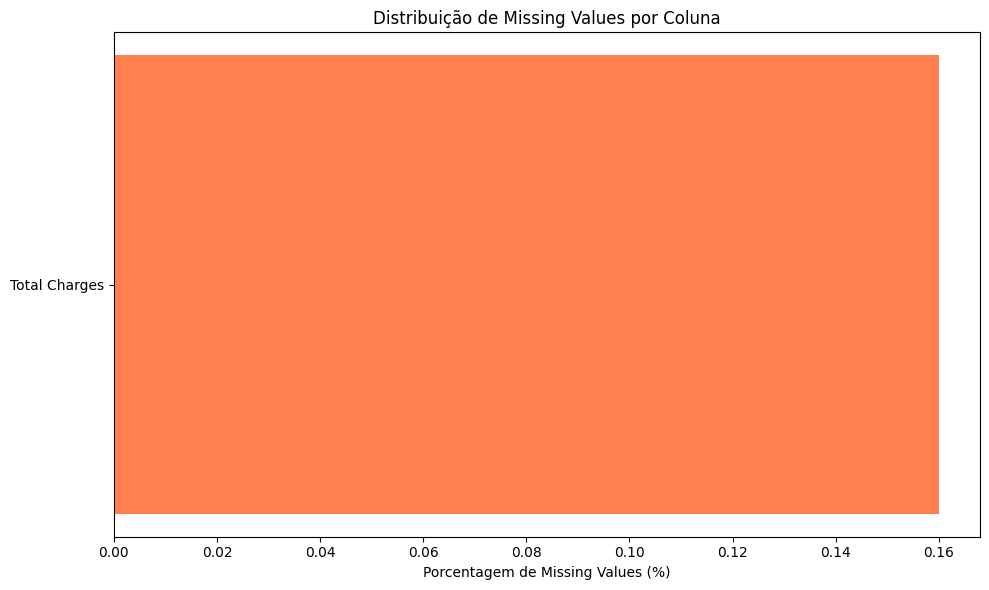

In [10]:
print("=== ANÁLISE DE MISSING VALUES ===\n")

df.drop('CustomerID', axis=1, inplace=True)
df.drop('Lat Long', axis=1, inplace=True)
df.drop('Churn Reason', axis=1, inplace=True)

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)
    
    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### - Identificado Valores faltantes → IDEAL SERIA 0

---

# DISTRIBUIÇÃO DA VARIÁVEL TARGET E PERCENTUAL

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
não churn (0): 73.46%
Churn (1): 26.54%


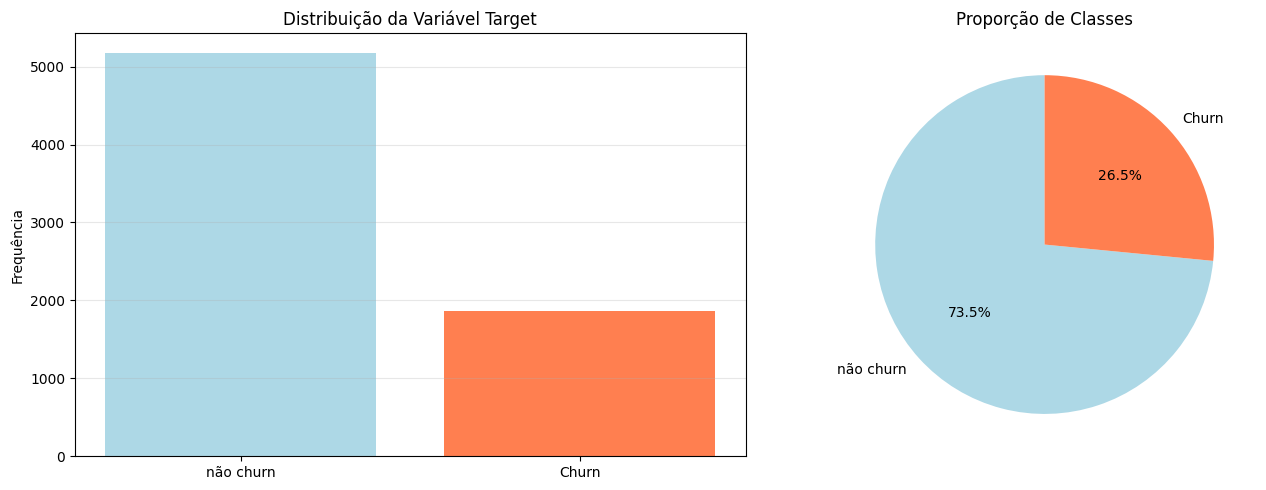


Ratio de balanceamento: 0.36
Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.



In [11]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

# No dataset original, valores = 0 indicam Não Churn e valores = 1 indicam Churn. Vamos transformar isso em uma variável binária.
df['target'] = (df['target'] > 0).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")

for idx, pct in target_percentages.items():
    label = "não churn" if idx == 0 else "Churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['não churn', 'Churn'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['não churn', 'Churn'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.\n")
else:
    print("✓ Dataset razoavelmente balanceado.")

### Qual opção escolher?
##### Comece com class_weight='balanced': É uma solução rápida, elegante e muitas vezes superior.
##### Tente SMOTE se: O class_weight não melhorar o recall (capacidade de detectar a classe minoritária) e se o seu dataset não for gigantesco.
##### Use variantes do SMOTE: Se houver muito ruído, prefira Borderline SMOTE ou SMOTE-ENN.

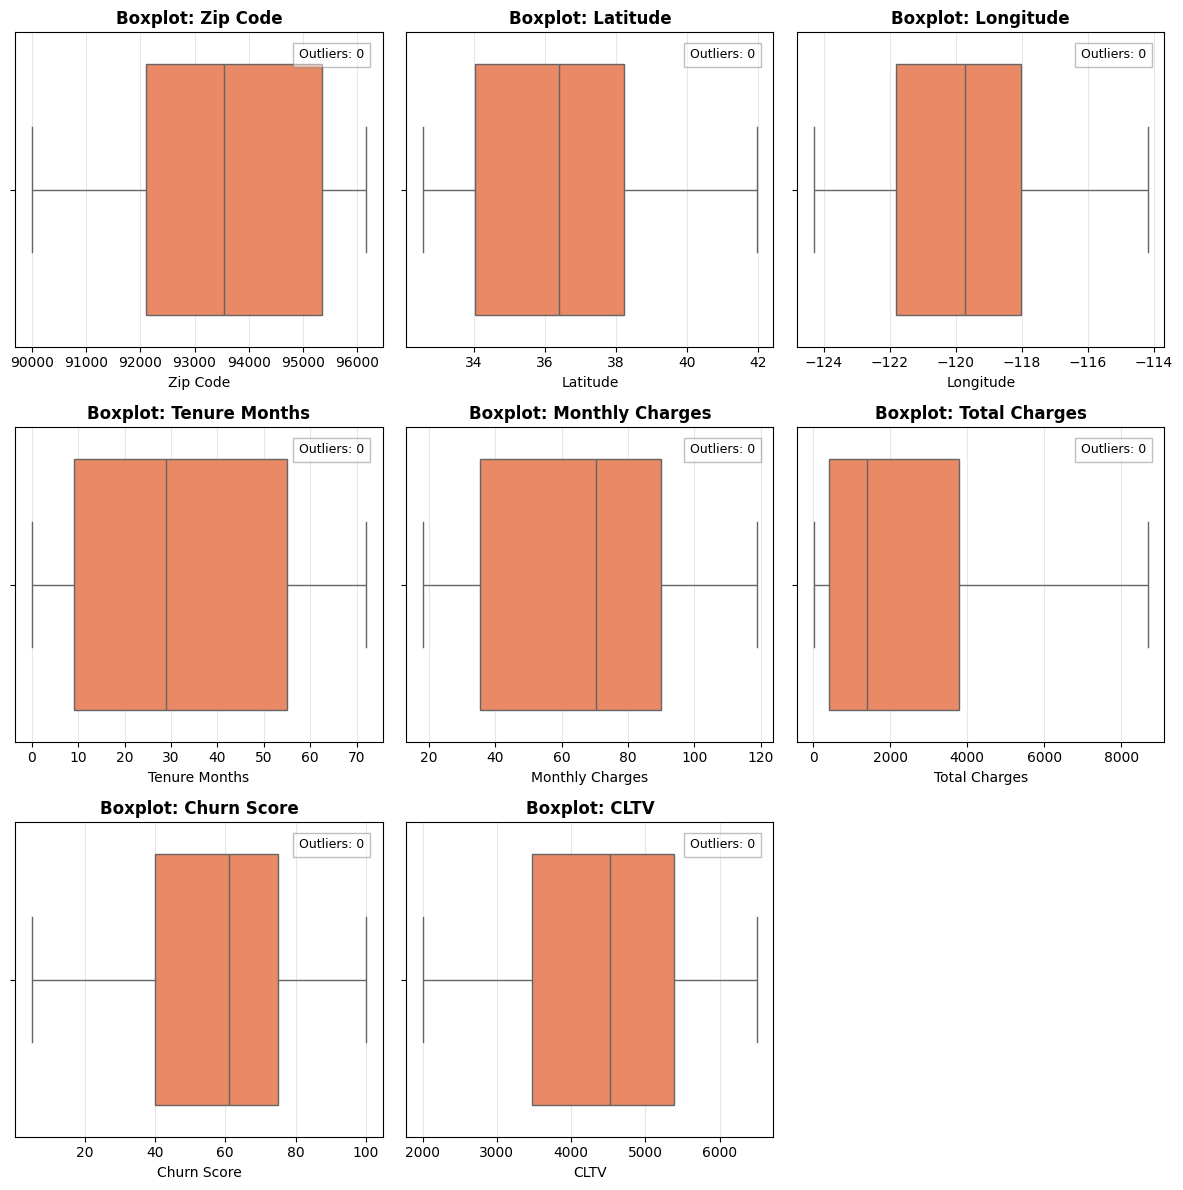

In [12]:
# Colunas numéricas (excluindo Count e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['Count','target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


---

# ANÁLISE UNIVARIADA

In [14]:
print("=== ANÁLISE UNIVARIADA ===\n")

categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns

for col in categorical_cols:
    print(df[col].value_counts(normalize=True))
    print("-"*80)


=== ANÁLISE UNIVARIADA ===

Country
United States    1.0
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
State
California    1.0
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
City
Los Angeles       0.043305
San Diego         0.021298
San Jose          0.015902
Sacramento        0.015334
San Francisco     0.014766
                    ...   
Milford           0.000568
Calpine           0.000568
Standish          0.000568
Tulelake          0.000568
Olympic Valley    0.000568
Name: proportion, Length: 1129, dtype: float64
--------------------------------------------------------------------------------
Gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64
--------------------------------------------------------------------------------
Senior Citizen
No     0.837853
Yes    0.162147
Name: proportion, dtype: float64
----------------------

### Insights importantes:
1. Contract: Month-to-month → Tende a churn alto
2. Internet Service: Fiber → Maior numero de churn
3. Payment Method: Electronic check → Maior numero de churn

---

# Categóricas vs Churn

=== GRÁFICOS DE BARRAS PARA VARIÁVEIS CATEGÓRICAS ===



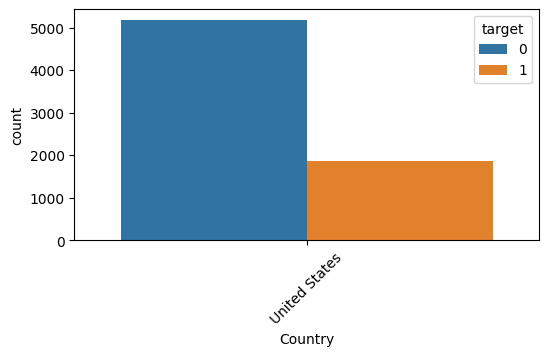

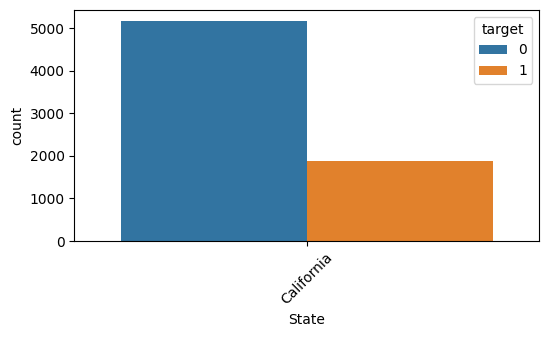

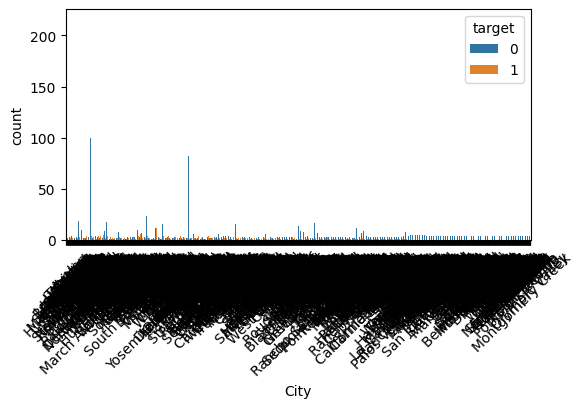

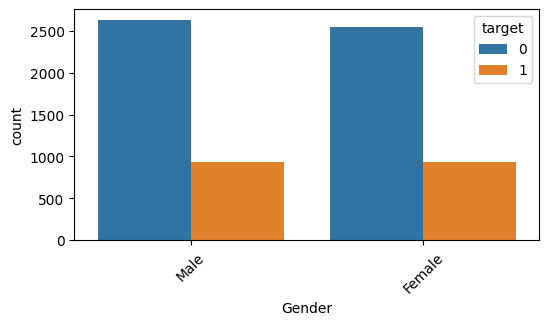

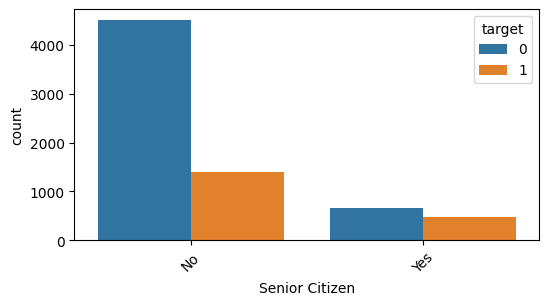

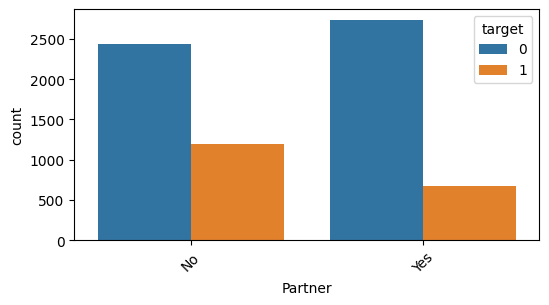

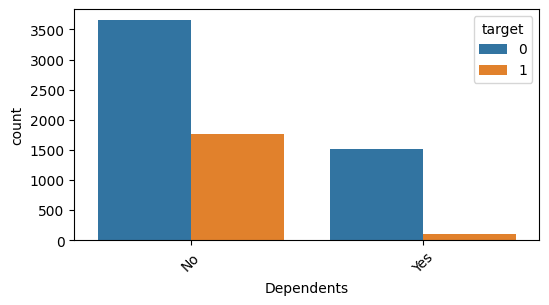

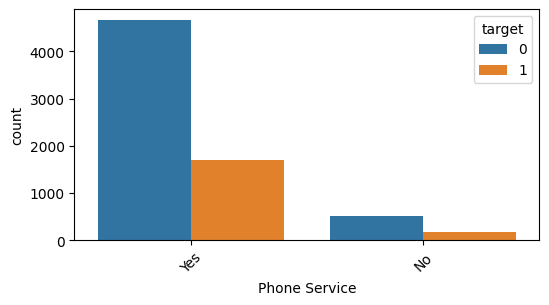

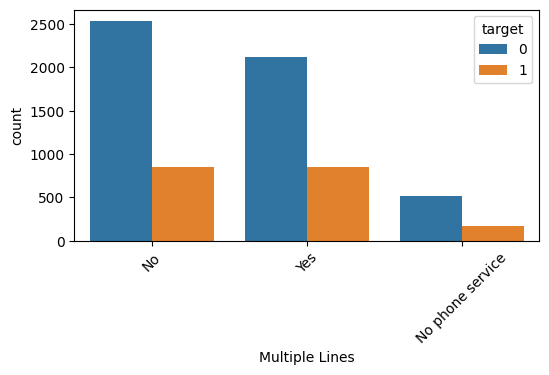

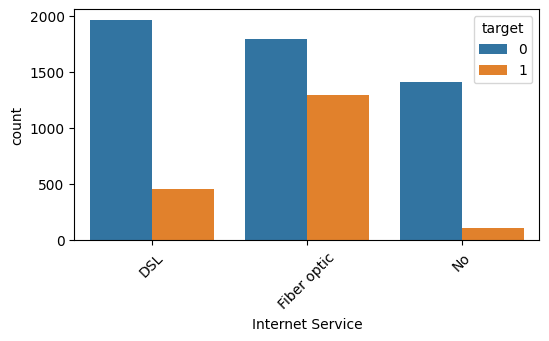

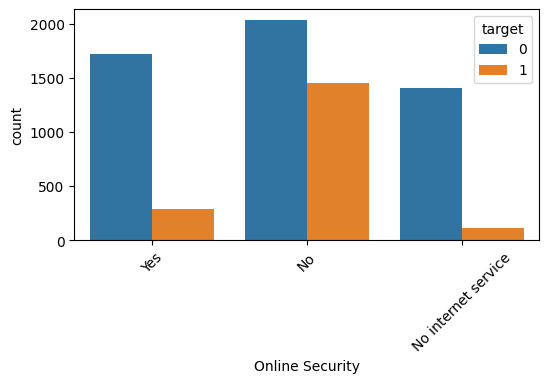

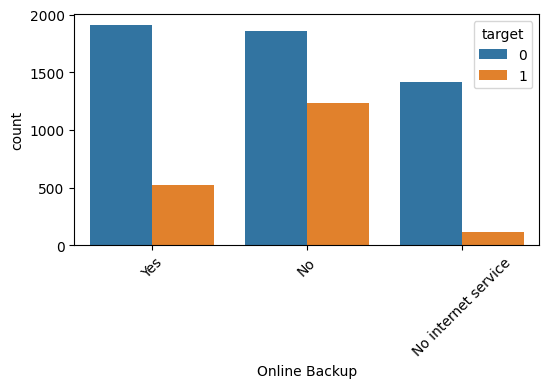

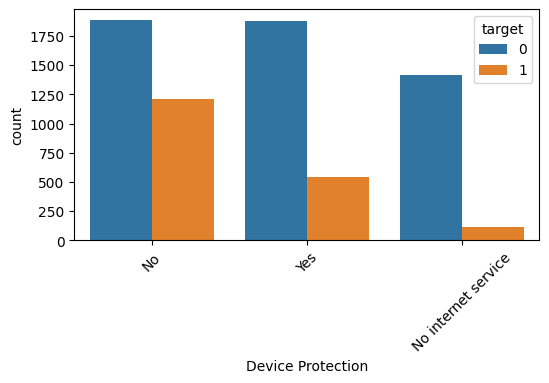

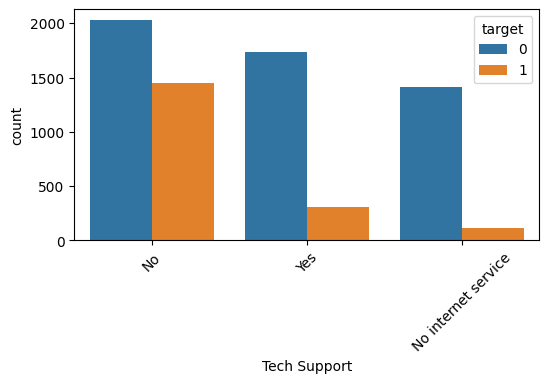

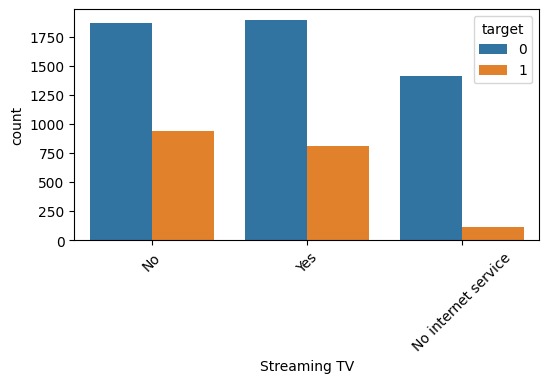

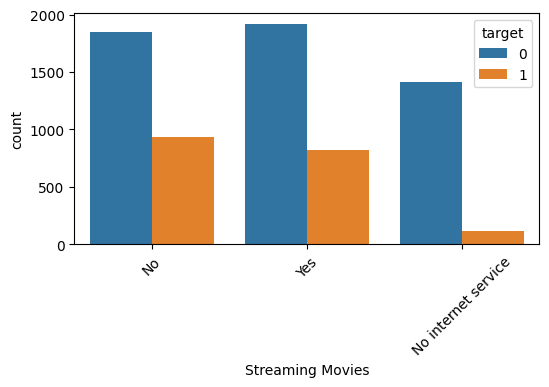

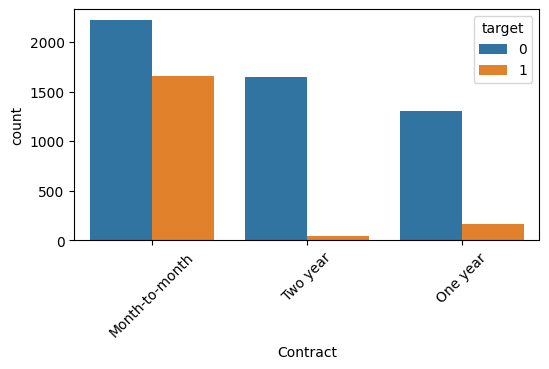

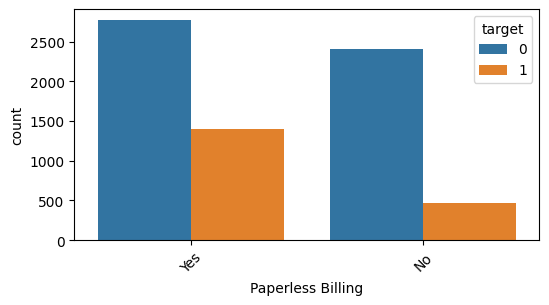

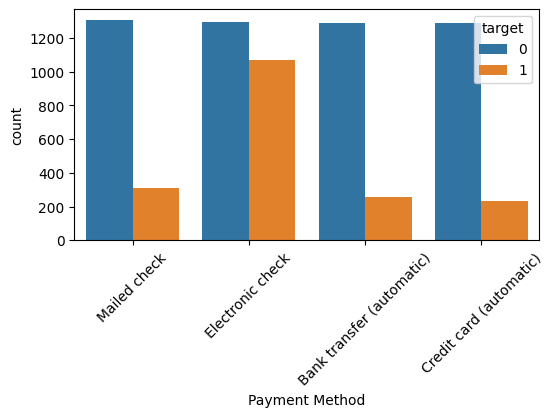

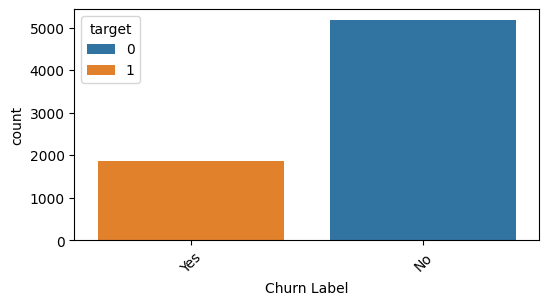

In [15]:
print("=== GRÁFICOS DE BARRAS PARA VARIÁVEIS CATEGÓRICAS ===\n")

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, hue="target")
    plt.xticks(rotation=45)
    plt.show()

### Insights Importantes:
1. Contract = Month-to-month → Numero alto de churn
2. Sem contrato longo → Risco alto de churn
3. Sem dependents → Numero alto de churn 

---

# Numéricas vs Churn

=== Numéricas vs Churn ===



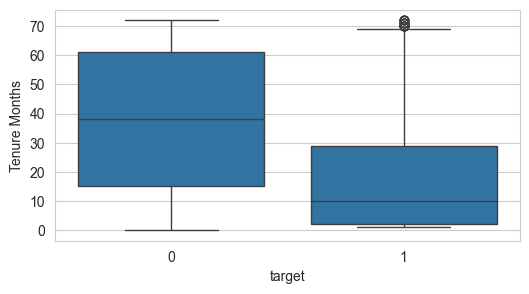

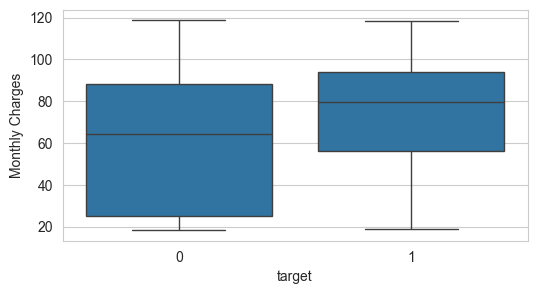

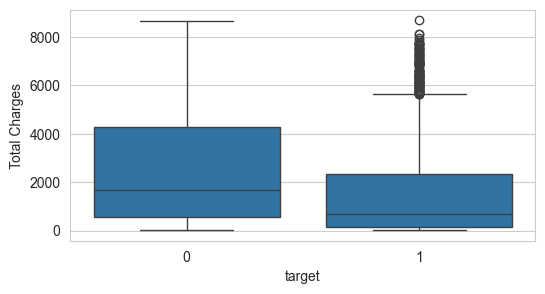

In [206]:
print("=== Numéricas vs Churn ===\n")

numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]

for col in numeric_cols:
    
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x="target", y=col)
    plt.show()

### Insights Importantes:
1. Tenure Months: Baixo → churn alto
2. Monthly Charges: Alto → churn maior
3. Total Charges: Clientes churn → valores menores (tempo curto)

---

# MATRIZ DE CORRELAÇÃO

=== MATRIZ DE CORRELAÇÃO ===



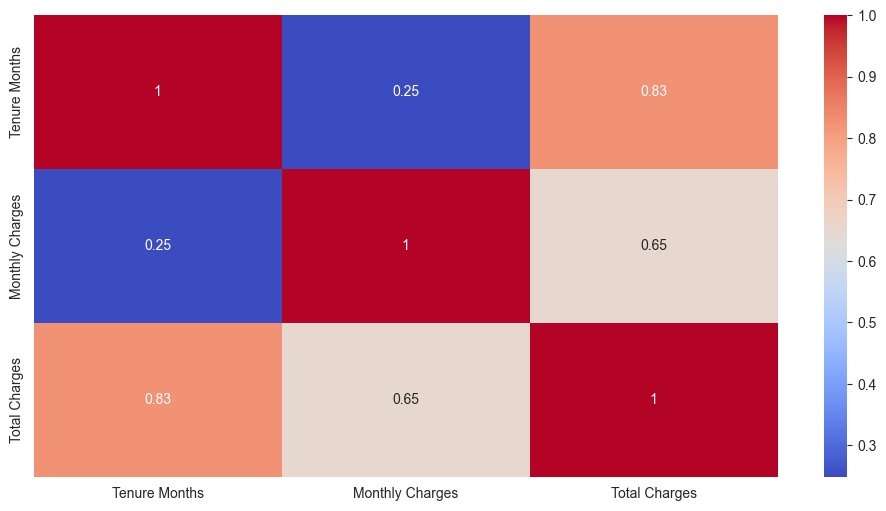

In [ ]:
print("=== MATRIZ DE CORRELAÇÃO ===\n")

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Insight Importante:

1. Total Charges correlaciona com Tenure Months

---

# FEATURE ENGINEERING

In [17]:
print("=== FEATURE ENGINEERING ===\n")

df["tenure_group"] = pd.cut(df["Tenure Months"], bins=[0,12,24,48,72])
df["avg_ticket"] = (df["Total Charges"] / (df["Tenure Months"] + 1))

print(df[["tenure_group", "avg_ticket"]])

=== FEATURE ENGINEERING ===

     tenure_group  avg_ticket
0         (0, 12]   36.050000
1         (0, 12]   50.550000
2         (0, 12]   91.166667
3        (24, 48]  105.036207
4        (48, 72]  100.726000
...           ...         ...
7038     (48, 72]   19.443836
7039     (12, 24]   79.620000
7040     (48, 72]  100.861644
7041      (0, 12]   28.870833
7042     (48, 72]  102.156716

[7043 rows x 2 columns]


---

# - Conclusão do EDA

### A análise exploratória revelou que o churn está fortemente associado ao tempo de permanência (Tenure Months), tipo de contrato e valor mensal cobrado. Clientes com contratos mensais, baixo tempo de relacionamento e altas cobranças apresentam maior probabilidade de cancelamento. O dataset apresenta desbalanceamento de classes e requer pré-processamento adequado, incluindo tratamento de variáveis categóricas e normalização.